# AML s26 - Principal Component Analysis (PCA) — Example 1


### Load Libraries, ... 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as sklearnPCA

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

---
### 1)  Generate Correlated 2-D Data

Create 200 points drawn from a multivariate normal distribution with
a strong positive correlation between the two features

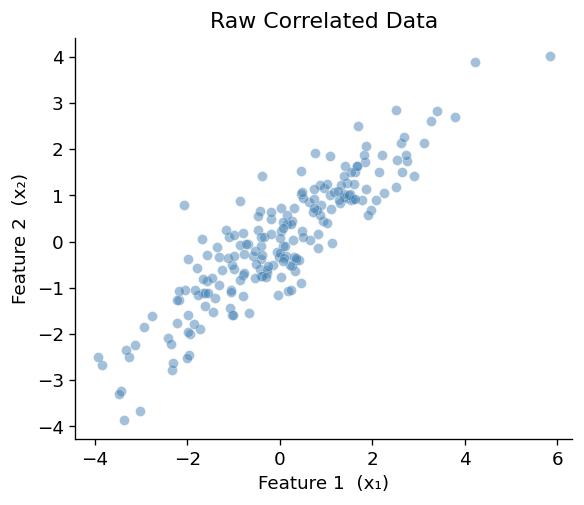

Data shape: (200, 2)   |   Sample mean: [-0.023  0.006]


In [2]:
mean = [0, 0]
cov_true = [[3.0, 2.2],
            [2.2, 2.0]]          # off-diagonal → correlation

X = np.random.multivariate_normal(mean, cov_true, size=200)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, edgecolors='white', linewidth=0.3, color='steelblue')
ax.set_xlabel('Feature 1  (x₁)')
ax.set_ylabel('Feature 2  (x₂)')
ax.set_title('Raw Correlated Data')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
print(f'Data shape: {X.shape}   |   Sample mean: {X.mean(axis=0).round(3)}')

---
### 2)  Center the data and compute the covariance matrix $\mathbf{C} = \frac{1}{n-1}\,\mathbf{X}_{c}^{\top}\mathbf{X}_{c}$

Note: $X_c$ ... is the centered version of $X$!

The covariance matrix captures **how features vary together**.  
Diagonal entries = variances; off-diagonal = covariances.

Covariance Matrix C (manual):
[[2.726 2.023]
 [2.023 1.864]]

numpy cross-check: True

Var(x₁) = 2.726,  Var(x₂) = 1.864
Cov(x₁,x₂) = 2.023  ← strong positive covariance


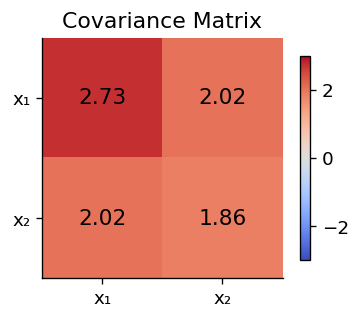

In [3]:
# center (zero-mean) the data
X_c = X - X.mean(axis=0)

# covariance matrix — manual calculation
n = X_c.shape[0]
C = (X_c.T @ X_c) / (n - 1)

print('Covariance Matrix C (manual):')
print(C.round(3))
print()
print('numpy cross-check:', np.allclose(C, np.cov(X_c.T)))
print(f'\nVar(x₁) = {C[0,0]:.3f},  Var(x₂) = {C[1,1]:.3f}')
print(f'Cov(x₁,x₂) = {C[0,1]:.3f}  ← strong positive covariance')

# show as heatmap
fig, ax = plt.subplots(figsize=(3.5, 2.8))
im = ax.imshow(C, cmap='coolwarm', vmin=-3, vmax=3)
plt.colorbar(im, ax=ax, shrink=0.85)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{C[i,j]:.2f}', ha='center', va='center', fontsize=13,
                color='black')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['x₁','x₂']); ax.set_yticklabels(['x₁','x₂'])
ax.set_title('Covariance Matrix')
plt.tight_layout(); plt.show()

---
### 3)  Eigendecomposition of the covariance Matrix


In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(C)   # eigh for symmetric matrices

# Sort descending
order = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]            # columns are eigenvectors

print('Eigenvalues  (= variance explained per PC):')
for i, lam in enumerate(eigenvalues):
    pct = lam / eigenvalues.sum() * 100
    print(f'  λ{i+1} = {lam:.4f}   →  {pct:.1f}% of total variance')

print('\nEigenvectors (columns = principal component directions):')
print(eigenvectors.round(4))
print()
print('Orthogonality check  u1·u2 =', eigenvectors[:,0] @ eigenvectors[:,1])

Eigenvalues  (= variance explained per PC):
  λ1 = 4.3633   →  95.1% of total variance
  λ2 = 0.2269   →  4.9% of total variance

Eigenvectors (columns = principal component directions):
[[-0.7773  0.6291]
 [-0.6291 -0.7773]]

Orthogonality check  u1·u2 = 0.0


### Show eigenvectors on top of the data

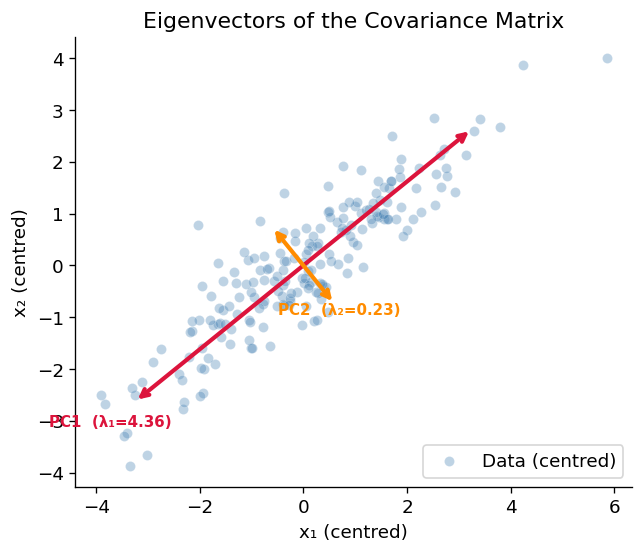

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(X_c[:, 0], X_c[:, 1], alpha=0.35, color='steelblue', edgecolors='white', linewidth=0.3, label='Data (centred)')

colors = ['crimson', 'darkorange']
labels = ['PC1  (λ₁={:.2f})'.format(eigenvalues[0]),    'PC2  (λ₂={:.2f})'.format(eigenvalues[1])]

for i in range(2):
    u   = eigenvectors[:, i]
    scale = np.sqrt(eigenvalues[i]) * 2   # length ∝ std-dev
    ax.annotate('', xy=scale*u, xytext=-scale*u, arrowprops=dict(arrowstyle='<->', color=colors[i], lw=2.5))
    ax.text(*(scale*u*1.15), labels[i], color=colors[i], fontsize=9, fontweight='bold', ha='center', va='center')

ax.set_xlabel('x₁ (centred)')
ax.set_ylabel('x₂ (centred)')
ax.set_title('Eigenvectors of the Covariance Matrix')
ax.set_aspect('equal')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

---
### 4)  Project data onto Principal components

In the new coordinate system the axes are **uncorrelated** (covariance ≈ 0).

Covariance in PC space (should be diagonal):
[[4.3633 0.    ]
 [0.     0.2269]]


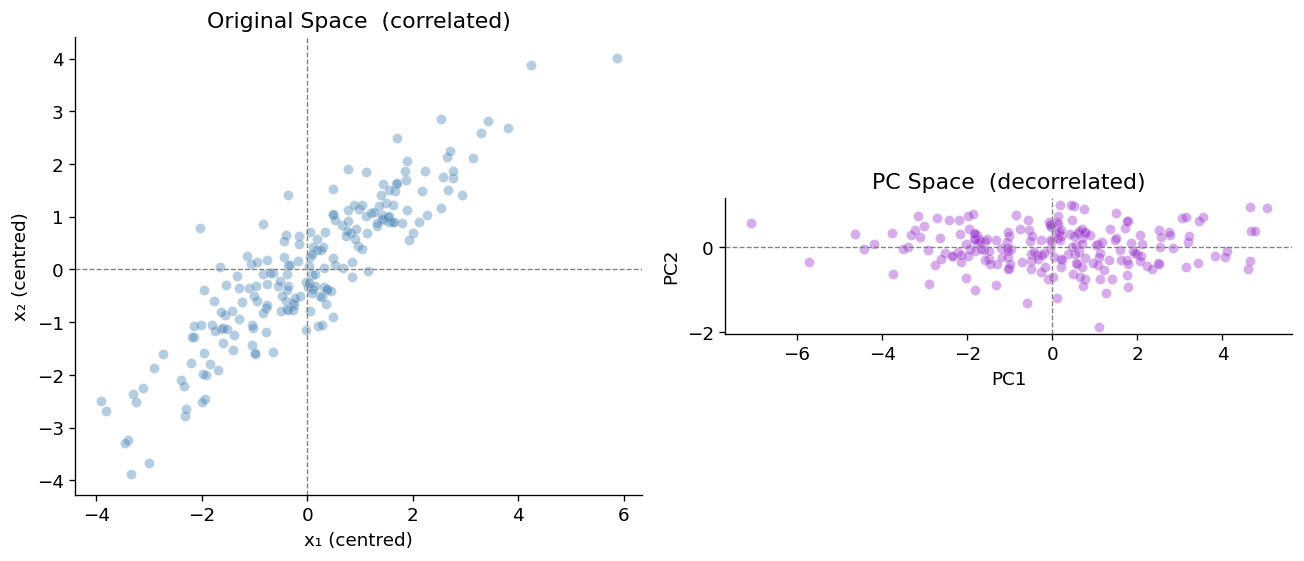

In [6]:
U = eigenvectors                        # (2×2) projection matrix
Z = X_c @ U                            # (200×2) projected scores

print('Covariance in PC space (should be diagonal):')
print(np.cov(Z.T).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Original space
axes[0].scatter(X_c[:,0], X_c[:,1], alpha=0.4, color='steelblue', edgecolors='white', lw=0.3)
axes[0].set_xlabel('x₁ (centred)'); axes[0].set_ylabel('x₂ (centred)')
axes[0].set_title('Original Space  (correlated)')
axes[0].set_aspect('equal')

# PC space
axes[1].scatter(Z[:,0], Z[:,1], alpha=0.4, color='darkorchid',  edgecolors='white', lw=0.3)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PC Space  (decorrelated)')
axes[1].set_aspect('equal')

for ax in axes:
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='grey', lw=0.8, ls='--')

plt.tight_layout(); plt.show()

---
### 5)  Dimensionality reduction and reconstruction

Keep only **PC1** (1D projection).  
The reconstruction error tells us how much information we discarded.

Variance explained by PC1: 95.1%
Mean squared reconstruction error: 0.1129


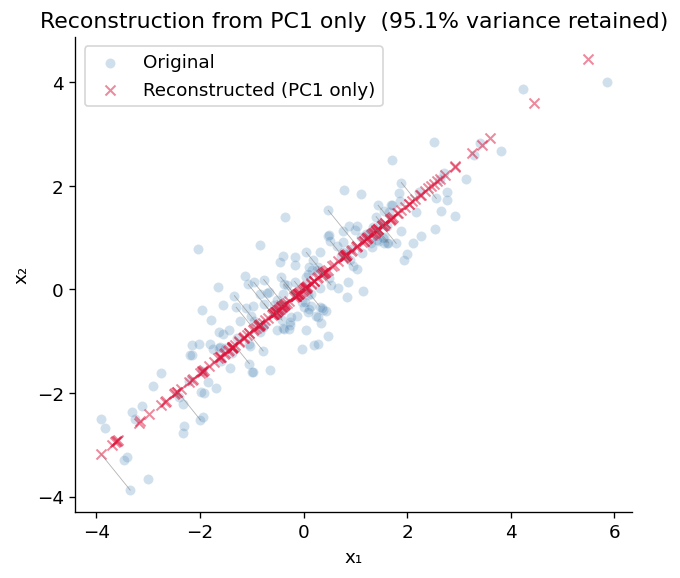

In [7]:
# Project onto PC1 only
Z_1d = X_c @ eigenvectors[:, [0]]          # (200×1)
X_reconstructed = Z_1d @ eigenvectors[:, [0]].T   # back to 2D

var_explained = eigenvalues[0] / eigenvalues.sum()
recon_error   = np.mean((X_c - X_reconstructed)**2)

print(f'Variance explained by PC1: {var_explained*100:.1f}%')
print(f'Mean squared reconstruction error: {recon_error:.4f}')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(X_c[:,0], X_c[:,1], alpha=0.25, color='steelblue', label='Original', edgecolors='white', lw=0.3)
ax.scatter(X_reconstructed[:,0], X_reconstructed[:,1], alpha=0.5, color='crimson', label='Reconstructed (PC1 only)', marker='x', linewidths=1.2)

# Draw residual lines
for i in range(0, 200, 5):
    ax.plot([X_c[i,0], X_reconstructed[i,0]],   [X_c[i,1], X_reconstructed[i,1]], 'grey', lw=0.5, alpha=0.6)

ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title(f'Reconstruction from PC1 only  ({var_explained*100:.1f}% variance retained)')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()